In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import math

In [2]:
analysis_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/8630_8730_mhz/'
decay_dir = os.path.join(analysis_dir, 'decay')
ann_dir = os.path.join(analysis_dir, 'ann')

In [3]:
decay_files = [file for file in os.listdir(decay_dir) if file.endswith('.npy')]
ann_files = [file for file in os.listdir(ann_dir) if file.endswith('.npy')]

decay_sizes = np.load(os.path.join(decay_dir, decay_files[0]))[0]
ann_sizes = np.load(os.path.join(ann_dir, decay_files[0]))[0]
decay_sizes, ann_sizes

(array([3.e-29, 2.e-29, 1.e-29, 8.e-30, 5.e-30]),
 array([1.e-25, 5.e-26, 3.e-26, 2.e-26, 1.e-26]))

In [4]:
decay_pvals = [np.load(os.path.join(decay_dir, file))[1] for file in decay_files]
ann_pvals = [np.load(os.path.join(ann_dir, file))[1] for file in ann_files]
decay_pvals, ann_pvals

([array([1.32558221e-46, 7.64871367e-30, 5.24603327e-21, 8.27636516e-18,
         3.37713048e-07]),
  array([2.28033512e-52, 5.87845089e-28, 1.60389218e-09, 5.99846194e-08,
         6.51833032e-11]),
  array([4.40096741e-38, 5.70584324e-19, 1.83264214e-13, 3.58033773e-14,
         9.95648864e-09]),
  array([5.97120632e-11, 5.70081006e-08, 7.56243135e-05, 2.19517891e-04,
         5.40105905e-03]),
  array([5.39417895e-06, 1.01819855e-03, 1.43185500e-02, 1.64353948e-02,
         1.47994309e-01])],
 [array([2.74376913e-73, 6.75389329e-29, 7.92504285e-19, 4.86971714e-17,
         3.55315034e-09]),
  array([4.24072969e-140, 9.72071217e-050, 1.21657062e-037, 1.60554097e-039,
         2.04969010e-019]),
  array([1.24229787e-141, 3.32765317e-054, 5.13664605e-037, 2.75121069e-023,
         2.06352491e-006]),
  array([8.60870956e-33, 2.36328684e-17, 3.31518046e-11, 1.09091303e-06,
         2.92208751e-02]),
  array([6.55547421e-16, 7.75000086e-07, 1.52161394e-02, 2.19708696e-02,
         1.88265

## Limit finder

In [5]:
#for decay_vals, ann_vals in zip(decay_pvals, ann_pvals):
from itertools import starmap

def get_limits(decay, ann):    
    def get_limit(sizes, vals):
        three_sigma = np.log10(.5*math.erfc(3/np.sqrt(2)))
        
        above = np.array([sizes[vals > three_sigma], vals[vals > three_sigma]])
        below = np.array([sizes[vals < three_sigma], vals[vals < three_sigma]])
        
        above_sort_indices = np.argsort(above[0])[::-1]
        above = above[:, above_sort_indices]
        below_sort_indices = np.argsort(below[0])[::-1]
        below = below[:, below_sort_indices]
        
        #print(above, below)

        if above.size > 0 and below.size > 0:
            ys = [below[0,-1], above[0,0]]
            xs = [below[1,-1], above[1,0]]
            
            print(xs, ys)

            return np.interp(three_sigma, xs, ys)
        
        elif above.size > 0:
            above_pts = above[:,:3]
            fit = np.polyfit(above_pts[1], above_pts[0], 1)
            
            return np.poly1d(fit)(three_sigma)
        
        elif below.size > 0:
            below_pts = below[:,-3:]
            fit = np.polyfit(below_pts[1], below_pts[0], 1)
            
            return np.poly1d(fit)(three_sigma)
    
    return list(starmap(get_limit, [decay, ann]))


[-3.6585300781221894, -2.2675210741965217] [-29.096910013008056, -29.30102999566398]
[-5.962209870748809, -1.534306781447709] [-25.69897000433602, -26.0]
[-2.992167525685783, -1.8441009590892685] [-28.69897000433602, -29.0]
[-6.110698249287332, -1.8176955214679633] [-25.30102999566398, -25.522878745280337]


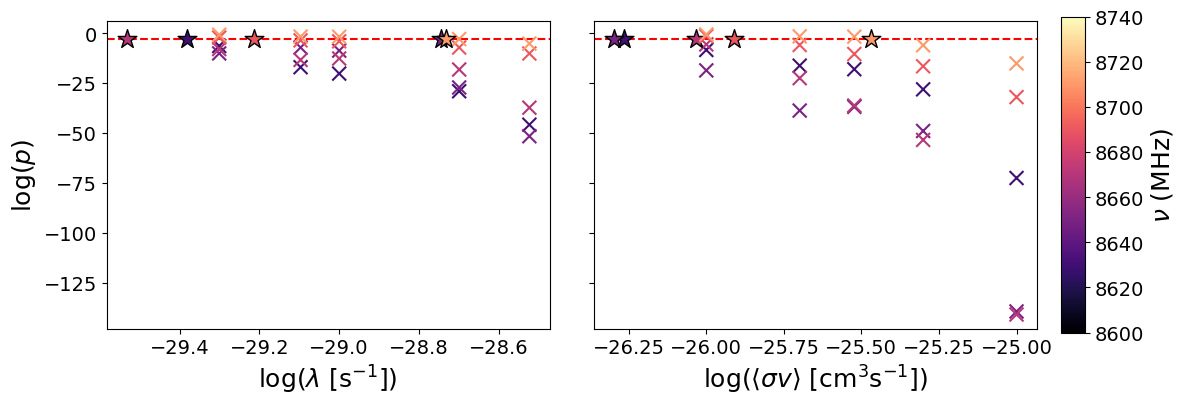

In [16]:
from matplotlib.colors import Normalize
from scipy.optimize import curve_fit

plt.rcParams.update({'font.size': 14})

norm = Normalize(vmin=8600, vmax=8740)
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plt.subplots_adjust(wspace=0.1)

freqs = np.arange(8630, 8730, 20)
cmap = plt.get_cmap('viridis')

# def power_law(x, a, b, c):
#     return a * (x**b) + c

decay_limits = []
ann_limits = []

three_sigma = np.log10(.5*math.erfc(3/np.sqrt(2)))

for decay_vals, ann_vals, freq in zip(decay_pvals, ann_pvals, freqs):
    decay_sizes_, decay_vals_ = np.log10(decay_sizes), np.log10(decay_vals)
    ann_sizes_, ann_vals_ = np.log10(ann_sizes), np.log10(ann_vals)
    
    sc_decay = axs[0].scatter(decay_sizes_, decay_vals_, c=freq*np.ones(5), cmap='magma', norm=norm, marker='x', s=100)
    sc_ann = axs[1].scatter(ann_sizes_, ann_vals_, c=freq*np.ones(5), cmap='magma', norm=norm, marker='x', s=100)
    
    decay_limit, ann_limit = get_limits(
        (decay_sizes_, decay_vals_),
        (ann_sizes_, ann_vals_)
    )
    
    decay_limits.append(decay_limit)
    ann_limits.append(ann_limit)
    
    axs[0].scatter(decay_limit, three_sigma, c=freq, cmap='magma', norm=norm, marker='*', s=200, edgecolors='black')
    axs[1].scatter(ann_limit, three_sigma, c=freq, cmap='magma', norm=norm, marker='*', s=200, edgecolors='black')
    
#     decay_xs = np.linspace(min(decay_sizes_), max(decay_sizes_))
#     decay_params = np.polyfit(decay_sizes_, decay_vals_, 1)
#     decay_fit = np.poly1d(decay_params)(decay_xs)
#     axs[0].plot(decay_xs, decay_fit, c=cmap(norm(freq)))
    
#     ann_xs = np.linspace(min(ann_sizes_), max(ann_sizes_))
#     ann_params = np.polyfit(ann_sizes_, ann_vals_, 1)
#     ann_fit = np.poly1d(ann_params)(ann_xs)
#     axs[1].plot(ann_xs, ann_fit, c=cmap(norm(freq)))
    
#     decay_xs = np.linspace(min(decay_sizes), max(decay_sizes)) * 1/(3e-29)
#     ann_xs = np.linspace(min(ann_sizes), max(ann_sizes)) * 1/(1e-25)

#     decay_params, _ = curve_fit(power_law, decay_sizes, decay_vals, p0=[1, -1, 0], maxfev=100000)
#     decay_fit = power_law(decay_xs, *decay_params)
#     ann_params, _ = curve_fit(power_law, ann_sizes, ann_vals, p0=[1, -1, 0], maxfev=100000)
#     ann_fit = power_law(ann_xs, *ann_params)
    
#     axs[0].plot(decay_xs*3e-29, decay_fit, c=cmap(norm(freq)))
#     axs[1].plot(ann_xs*1e-25, ann_fit, c=cmap(norm(freq)))


axs[0].set_xlabel('log($\lambda$ [s$^{-1}$])', fontsize=18)
axs[0].set_ylabel('log($p$)', fontsize=18)
axs[0].axhline(three_sigma, c='red', ls='--', zorder=-1)

axs[1].set_xlabel(r'log($\langle \sigma v \rangle$ [cm$^3$s$^{-1}$])', fontsize=18)
axs[1].axhline(three_sigma, c='red', ls='--', zorder=-1)

cax = fig.add_axes([0.92, 0.10, 0.02, 0.79]) 
cbar = fig.colorbar(sc_decay, cax=cax, orientation='vertical')
cbar.set_label(label=r'$\nu$ (MHz)', size=18)

plt.savefig('/home/bhanselman/images/first_analysis_pvals_w_limits.png', bbox_inches='tight', dpi=500)

In [13]:
three_sigma

-2.8696990359293686

In [30]:
decay_limits, ann_limits

([-29.381062880607907,
  -28.74535237498093,
  -29.532926979374302,
  -29.212664963692372,
  -28.73108198286845],
 [-26.266609079365367,
  -26.297775994291374,
  -26.032827685334752,
  -25.90921365791685,
  -25.46851454402724])

# Exclusion

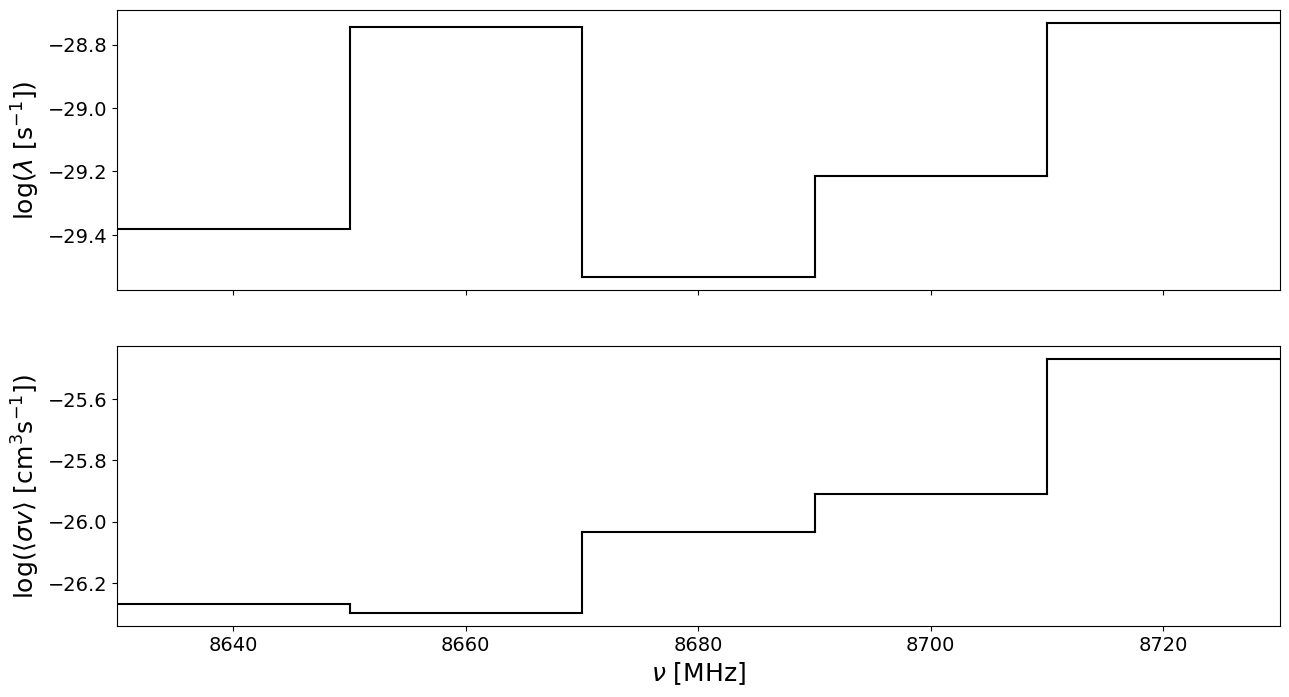

In [14]:
fig, axs = plt.subplots(2, 1, figsize=(15,8), sharex=True)
plt.subplots_adjust(wspace=0.2)

for i, freq in enumerate(freqs):
    axs[0].plot([freq, freq+20], [decay_limits[i], decay_limits[i]], c='k')
    axs[1].plot([freq, freq+20], [ann_limits[i], ann_limits[i]], c='k')
    if i != len(freqs) - 1:
        axs[0].plot([freq+20, freq+20], [decay_limits[i], decay_limits[i+1]], c='k')
        axs[1].plot([freq+20, freq+20], [ann_limits[i], ann_limits[i+1]], c='k')

axs[0].set_ylabel(r'log($\lambda$ [s$^{-1}$])', fontsize=18)
axs[1].set_xlabel(r'$\nu$ [MHz]', fontsize=18)
axs[1].set_ylabel(r'log($\langle \sigma v \rangle$ [cm$^3$s$^{-1}$])', fontsize=18)
axs[1].set_xlim(freqs[0], freqs[-1]+20)

plt.savefig('/home/bhanselman/images/first_analysis_exclusion.png', bbox_inches='tight', dpi=500)

# Second analysis test

In [3]:
import numpy as np
import pandas as pd
import os
import multiprocessing as mp
import logging
from functools import partial
from tqdm import tqdm
import math
import matplotlib.pyplot as plt

three_sigma = np.log10(.5*math.erfc(3/np.sqrt(2)))

plt.rcParams.update({'font.size': 14, 'axes.labelsize': 14})

from scipy.interpolate import interp1d, make_interp_spline, PchipInterpolator, Akima1DInterpolator
from scipy.optimize import brentq

def get_limit(pval_array):
    sizes, vals = pval_array
    
    # Convert to log
    sizes, vals = np.log10(sizes), np.log10(vals)
    
    above = np.array([sizes[vals > three_sigma], vals[vals > three_sigma]])
    below = np.array([sizes[vals < three_sigma], vals[vals < three_sigma]])

    above_sort_indices = np.argsort(above[0])[::-1]
    above = above[:, above_sort_indices]
    below_sort_indices = np.argsort(below[0])[::-1]
    below = below[:, below_sort_indices]

    #print(above, below)

    if above.size > 0 and below.size > 0:
        ys = [below[0,-1], above[0,0]]
        xs = [below[1,-1], above[1,0]]

        return np.interp(three_sigma, xs, ys)

    elif above.size > 0:
        above_pts = above[:,:3]
        fit = np.polyfit(above_pts[1], above_pts[0], 1)

        return np.poly1d(fit)(three_sigma)

    elif below.size > 0:
        below_pts = below[:,-3:]
        fit = np.polyfit(below_pts[1], below_pts[0], 1)

        return np.poly1d(fit)(three_sigma)

    
def get_limit_interp(pval_array, interp_type='spline'):
    sizes, vals = pval_array
    # Throw out zero p-vals
    mask = vals != 0
    sizes, vals = sizes[mask], vals[mask]
    # Convert to log
    sizes, vals = np.log10(sizes), np.log10(vals)
    sort_indices = np.argsort(sizes)
    sizes, vals = sizes[sort_indices], vals[sort_indices]
    #print(sizes, vals)
    
    if interp_type == 'spline':
        spline = make_interp_spline(sizes, vals, k=3)
        xs = np.linspace(min(sizes), max(sizes), 1000)
        fit = interp1d(xs, spline(xs), bounds_error=False, fill_value='extrapolate')
    elif interp_type == 'pchip':
        fit = PchipInterpolator(sizes, vals, extrapolate=True)
    elif interp_type == 'akima':
        fit = Akima1DInterpolator(sizes, vals, extrapolate=True)
    elif interp_type == 'makima':
        fit = Akima1DInterpolator(sizes, vals, method='makima', extrapolate=True)
        
    def target(x):
        return fit(x) - three_sigma
    
    try:
        limit = brentq(target, min(sizes), max(sizes))
    except:
        try:
            limit = brentq(target, -100, min(sizes))
        except:
            try:
                limit = brentq(target, min(sizes), 0)
            except:
                logging.warning(f'Root could not be found, interp_type={interp_type}')
                limit = None
    
    return fit, limit

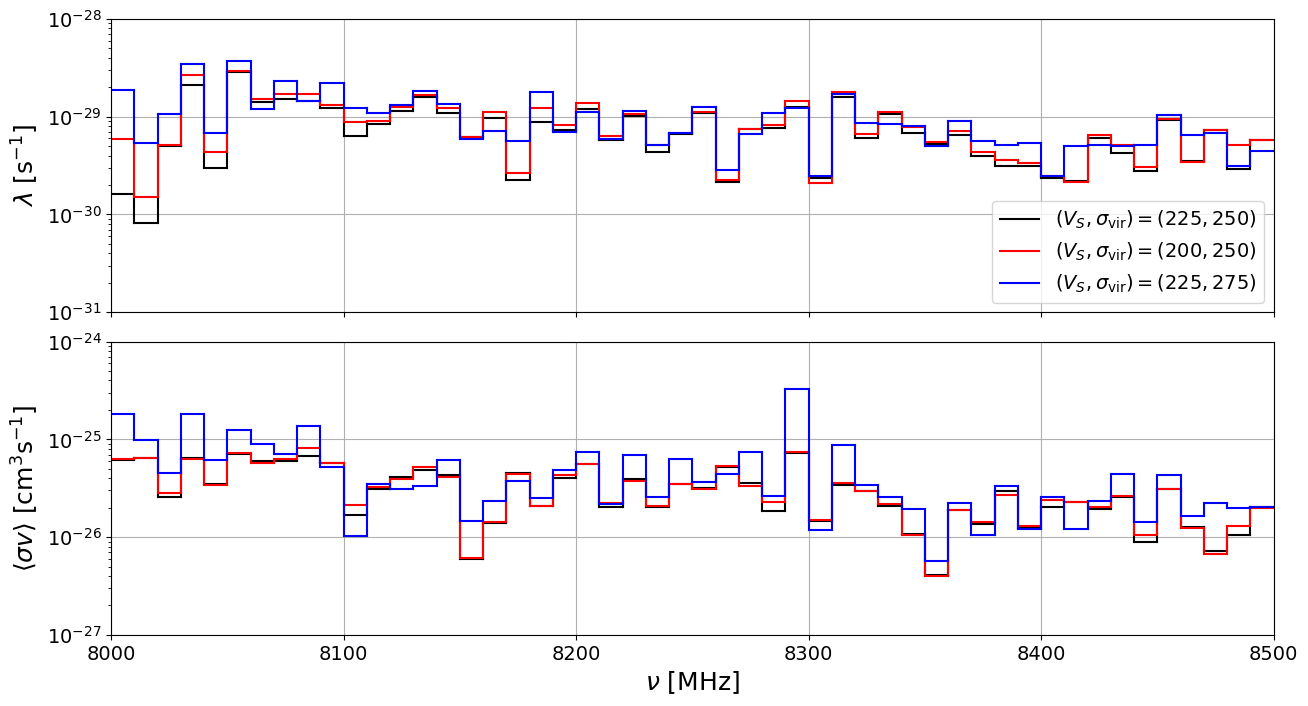

In [6]:
if __name__ == '__main__':
#     analysis_dirs_list = [
#         [
#             '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/8000_8500_mhz/decay',
#             '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/8000_8500_mhz_weighted/decay',
#             '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/8000_8500_mhz_weighted_optimized/decay',
#         ],
#         [
#             '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/8000_8500_mhz/ann',
#             '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/8000_8500_mhz_weighted/ann',
#             '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/8000_8500_mhz_weighted_optimized/ann',
#         ]
#     ]
    
#     colors = ['k', 'red', 'blue']
#     method_labels = ['pg', 'weighted', 'weighted opt']
#     labels = [
#         r'$\lambda$ [s$^{-1}$]',
#         r'$\langle \sigma v \rangle$ [cm$^3$s$^{-1}$]'
#     ]
    
    analysis_dirs_list = [
        [
            '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/8000_8500_mhz_weighted_optimized/decay',
            '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/8000_8500_mhz_weighted_optimized_v2/decay',
            '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/8000_8500_mhz_weighted_optimized_v3/decay',

        ],
        [
            '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/8000_8500_mhz_weighted_optimized/ann',
            '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/8000_8500_mhz_weighted_optimized_v2/ann',
            '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/8000_8500_mhz_weighted_optimized_v3/ann', 
        ]
    ]
    
    colors = ['k', 'red', 'blue']
    method_labels = [
        '$(V_S, \sigma_\mathrm{vir}) = (225, 250)$',
        '$(V_S, \sigma_\mathrm{vir}) = (200, 250)$',
        '$(V_S, \sigma_\mathrm{vir}) = (225, 275)$'
    ]
    labels = [
        r'$\lambda$ [s$^{-1}$]',
        r'$\langle \sigma v \rangle$ [cm$^3$s$^{-1}$]'
    ]
    
    fig, axs = plt.subplots(2, 1, figsize=(15,8), sharex=True)
    plt.subplots_adjust(hspace=0.1)
    
    for ax, analysis_dirs, label in zip(axs, analysis_dirs_list, labels):
        mins, maxes = [], []
        
        for analysis_dir, color, method_label in zip(analysis_dirs, colors, method_labels):
            files = [file for file in os.listdir(analysis_dir) if 'pvals' in file]
            files = sorted(files, key=lambda file: int(file.split('_')[0]))
            pval_arrays = [np.load(os.path.join(analysis_dir, file)) for file in files]
            freqs = [int(file.split('_')[0]) for file in files]
            #print(f'{method_label} pvals: {list(zip(freqs, pval_arrays))}')

            limits = [10 ** get_limit(pval_array) for pval_array in pval_arrays]
            #spline_limits = [10 ** get_limit_interp(pval_array, interp_type='spline')[1] for pval_array in pval_arrays]

            freq_diff = freqs[1] - freqs[0]
            for i in range(len(freqs)):
                if i != len(freqs) - 1:
                    ax.plot([freqs[i], freqs[i+1]], [limits[i], limits[i]], c=color)
                    ax.plot([freqs[i+1], freqs[i+1]], [limits[i], limits[i+1]], c=color)
                    #ax.plot([freqs[i], freqs[i+1]], [spline_limits[i], spline_limits[i]], ls='--', c=color)
                    #ax.plot([freqs[i+1], freqs[i+1]], [spline_limits[i], spline_limits[i+1]], ls='--', c=color)
                else:
                    ax.plot([freqs[i], freqs[i]+freq_diff], [limits[i], limits[i]], c=color, label=method_label)
                    #ax.plot([freqs[i], freqs[i]+freq_diff], [spline_limits[i], spline_limits[i]], c=color, ls='--', label=method_label)
                
            mins.append(min(limits))
            #mins.append(min(spline_limits))
            maxes.append(max(limits))
            #maxes.append(max(spline_limits))
            
        ax.set_ylabel(label, fontsize=18) #r'$\langle \sigma v \rangle$ [cm$^3$s$^{-1}$]' #r'$\lambda$ [s$^{-1}$]'
        
        ax.set_yscale('log')

        log_min, log_max = np.log10(min(mins)), np.log10(max(maxes))
        plot_min, plot_max = 10 ** math.floor(log_min), 10 ** math.ceil(log_max)
        ax.set_ylim(plot_min, plot_max)
        ax.grid()
    
    axs[0].legend(loc='best')#, bbox_to_anchor=(1, 1))
    axs[1].set_xlim(freqs[0], freqs[-1]+freq_diff)
    axs[1].set_xlabel(r'$\nu$ [MHz]', fontsize=18)
    
    plt.savefig('/home/bhanselman/images/second_analysis_exclusion_velocities_presentation.png', bbox_inches='tight', dpi=500)

## Checking exclusion calculations

In [10]:
%pip install --upgrade scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 29.5 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.10.0
    Uninstalling scipy-1.10.0:
      Successfully uninstalled scipy-1.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
Note: you may need to restart the kernel to use updated packages.


Text(0.5, 0.98, '$\\nu =$8380 MHz')

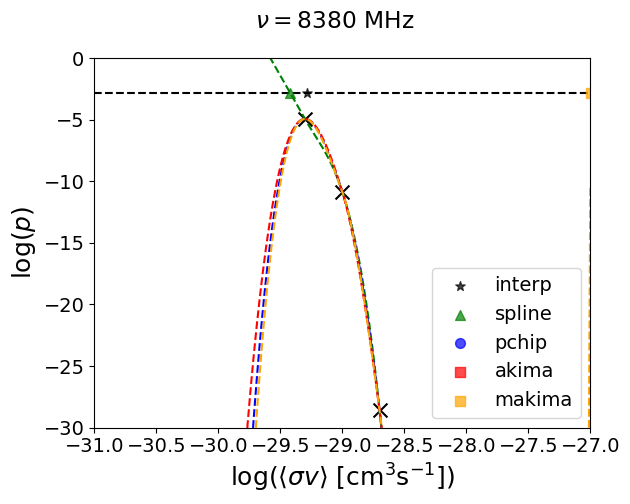

In [6]:
import random

freqs = np.arange(8000, 8500, 10).tolist()
i = random.randint(0, len(freqs))
i = freqs.index(8380)

analysis_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/8000_8500_mhz/decay'
files = [file for file in os.listdir(analysis_dir) if 'pvals' in file]
files = sorted(files, key=lambda file: int(file.split('_')[0]))
pval_arrays = [np.load(os.path.join(analysis_dir, file)) for file in files]
pval_arrays = [np.load(os.path.join(analysis_dir, file)) for file in files]

freq, pval_array = freqs[i], pval_arrays[i]

fig, ax = plt.subplots()
sizes, log_vals = np.log10(pval_array[0]), np.log10(pval_array[1])
ax.scatter(sizes, log_vals, marker='x', c='k', s=100)
limit = get_limit(pval_array)
spline, limit_spline = get_limit_interp(pval_array, interp_type='spline')
pchip, limit_pchip = get_limit_interp(pval_array, interp_type='pchip')
akima, limit_akima = get_limit_interp(pval_array, interp_type='akima')
makima, limit_makima = get_limit_interp(pval_array, interp_type='makima')

ax.scatter(limit, three_sigma, marker='*', s=50, c='k', alpha=0.7, label='interp')
ax.scatter(limit_spline, three_sigma, marker='^', s=50, c='green', alpha=0.7, label='spline')
ax.scatter(limit_pchip, three_sigma, marker='o', s=50, c='blue', alpha=0.7, label='pchip')
ax.scatter(limit_akima, three_sigma, marker='s', s=50, c='red', alpha=0.7, label='akima')
ax.scatter(limit_makima, three_sigma, marker='s', s=50, c='orange', alpha=0.7, label='makima')

xs = np.linspace(-31, -27, 1000)
ax.plot(xs, spline(xs), ls='--', c='green')
ax.plot(xs, pchip(xs), ls='--', c='blue')
ax.plot(xs, akima(xs), ls='--', c='red')
ax.plot(xs, makima(xs), ls='--', c='orange')

ax.axhline(three_sigma, c='k', ls='--', zorder=-1)
ax.set_xlabel(r'log($\langle \sigma v \rangle$ [cm$^3$s$^{-1}$])', fontsize=18)
ax.set_ylabel('log($p$)', fontsize=18)
ax.legend()
ax.set_xlim(-31, -27)
ax.set_ylim(-30, 0)

fig.suptitle(fr'$\nu =${freq} MHz')

# analysis_20251130

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os
import math

/tmp/ipykernel_1657381/1751818124.py:18: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=mpl.colormaps['viridis']), label='Iteration', ticks=bounds[:-1]) # Ticks in the middle of intervals


Text(0, 0.5, 'log($p$)')

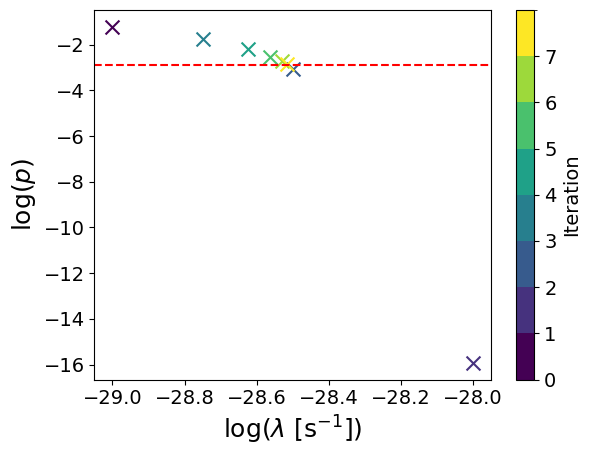

In [9]:
pval_example = np.load('/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/0/7760_pvals.npy')
sizes, vals = pval_example
sizes, vals = np.log10(sizes), np.log10(vals)

plt.rcParams.update({'font.size': 14})

cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, len(sizes)))
for i in range(len(sizes)):
    plt.scatter(sizes[i], vals[i], marker='x', color=colors[i], s=100)

import matplotlib as mpl
import matplotlib.colors as mcolors

bounds = np.arange(len(sizes)+1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)
discrete_cmap = mcolors.ListedColormap(colors)
plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=mpl.colormaps['viridis']), label='Iteration', ticks=bounds[:-1]) # Ticks in the middle of intervals

plt.axhline(np.log10(.5*math.erfc(3/np.sqrt(2))), c='red', ls='--')
plt.xlabel('log($\lambda$ [s$^{-1}$])', fontsize=18)
plt.ylabel('log($p$)', fontsize=18)

# Correlation linearity? (07/09/26)

In [10]:
from scipy.special import erfcinv

/tmp/ipykernel_1657381/105246905.py:18: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=mpl.colormaps['viridis'])) # Ticks in the middle of intervals


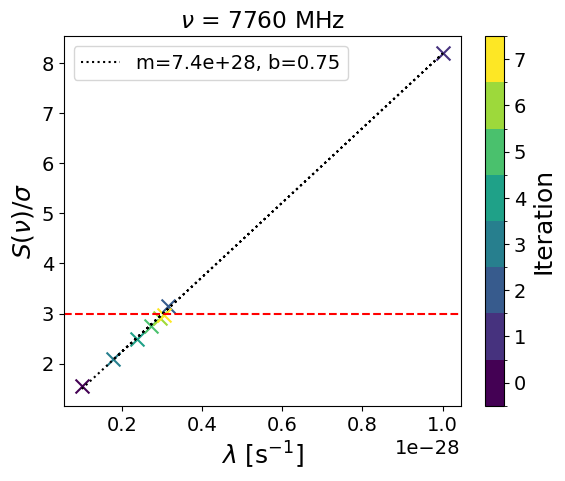

In [11]:
pval_example = np.load('/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/0/7760_pvals.npy')
sizes, vals = pval_example
vals = np.sqrt(2) * erfcinv(2 * vals)

plt.rcParams.update({'font.size': 14})

cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, len(sizes)))
for i in range(len(sizes)):
    plt.scatter(sizes[i], vals[i], marker='x', color=colors[i], s=100)

import matplotlib as mpl
import matplotlib.colors as mcolors

bounds = np.arange(len(sizes)+1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)
discrete_cmap = mcolors.ListedColormap(colors)
cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=mpl.colormaps['viridis'])) # Ticks in the middle of intervals
cbar.set_label('Iteration', fontsize=18)
cbar.set_ticks(bounds[:-1]+0.5)
cbar.set_ticklabels(bounds[:-1])


m, b = np.polyfit(sizes, vals, 1)
plt.plot(sizes, m * sizes + b, c='k', ls=':', label=f'm={m:.2g}, b={b:.2f}')

plt.axhline(3, c='red', ls='--')
plt.xlabel('$\lambda$ [s$^{-1}$]', fontsize=18)
plt.ylabel(r'$S(\nu) / \sigma$', fontsize=18)
plt.title(r'$\nu$ = 7760 MHz')
plt.legend()

/tmp/ipykernel_1657381/3528725378.py:18: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=mpl.colormaps['viridis'])) # Ticks in the middle of intervals


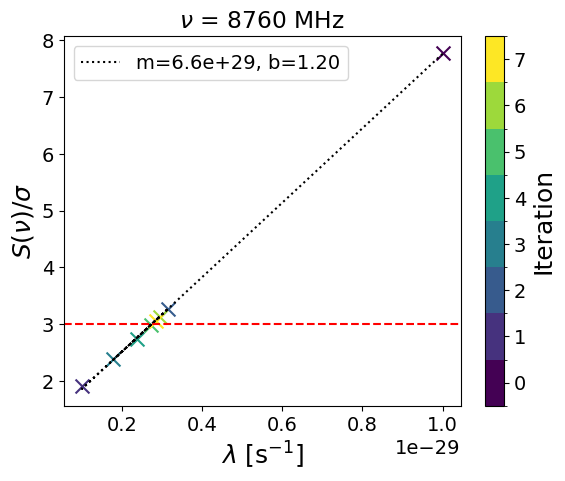

In [12]:
pval_example = np.load('/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/0/8760_pvals.npy')
sizes, vals = pval_example
vals = np.sqrt(2) * erfcinv(2 * vals)

plt.rcParams.update({'font.size': 14})

cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, len(sizes)))
for i in range(len(sizes)):
    plt.scatter(sizes[i], vals[i], marker='x', color=colors[i], s=100)

import matplotlib as mpl
import matplotlib.colors as mcolors

bounds = np.arange(len(sizes)+1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)
discrete_cmap = mcolors.ListedColormap(colors)
cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=mpl.colormaps['viridis'])) # Ticks in the middle of intervals
cbar.set_label('Iteration', fontsize=18)
cbar.set_ticks(bounds[:-1]+0.5)
cbar.set_ticklabels(bounds[:-1])


m, b = np.polyfit(sizes, vals, 1)
plt.plot(sizes, m * sizes + b, c='k', ls=':', label=f'm={m:.2g}, b={b:.2f}')

plt.axhline(3, c='red', ls='--')
plt.xlabel('$\lambda$ [s$^{-1}$]', fontsize=18)
plt.ylabel(r'$S(\nu) / \sigma$', fontsize=18)
plt.title(r'$\nu$ = 8760 MHz')
plt.legend()

## RSS for all X-band freqs (decay)

In [13]:
from numpy.polynomial import Polynomial
result = Polynomial.fit(sizes, vals, 1, full=True)
result[1][0][0]

0.005392038635723842

Bank 2:
[ 9850  9910 10010 10410 10440 10500 10510 10540 10570 10600 10780 10800
 10910 10920 10940 10970 10990 11000 11010 11050 11060 11070 11080 11090
 11100 11110]
Percent bad: 19.3%


Text(0, 0.5, '$S_I(\\nu)$')

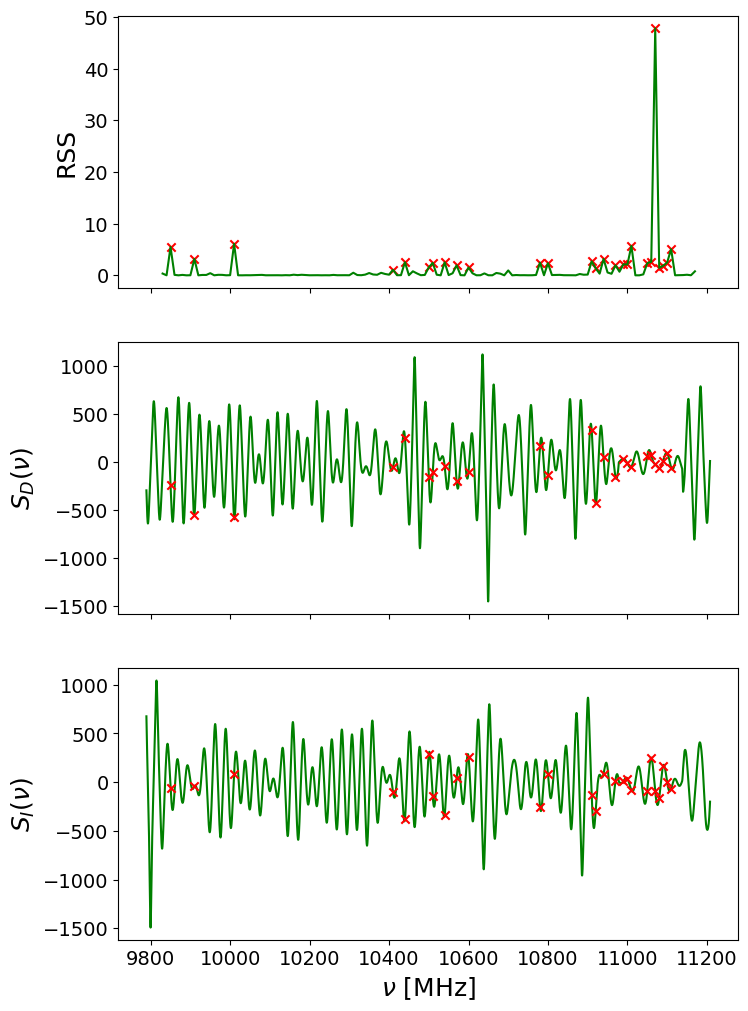

In [31]:
colors = ['blue', 'orange', 'green']
analysis_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/'

def key(l):
    return int(l.split('_')[0])

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8,12), sharex=True)

#for bank, color in enumerate(colors):
bank = 2
color = 'green'
print(f'Bank {bank}:')
bank_dir = os.path.join(analysis_dir, str(bank))
files = [file for file in os.listdir(bank_dir) if ('pvals' in file) and ('uninj' not in file)]
sorted_files = sorted(files, key=key)
pvals_list = np.array([np.load(os.path.join(bank_dir, file)) for file in sorted_files])

def get_rss(pvals):
    sizes, vals = pvals
    corrs = np.sqrt(2) * erfcinv(2 * vals)
    result = Polynomial.fit(sizes, corrs, 1, full=True)
    return result[1][0][0]

rss_vals = np.array([get_rss(pvals) for pvals in pvals_list])
freqs = np.array(list(map(key, sorted_files)))

# A bad fit whenever rss > 1
inds = np.where(rss_vals > 1)[0]
percent = len(inds) / len(rss_vals)
bad_freqs = freqs[inds]
print(bad_freqs)
print(f'Percent bad: {(percent * 100):.1f}%')

ax1.plot(freqs, rss_vals, color=color)
ax1.scatter(bad_freqs, rss_vals[inds], color='r', marker='x')

dopp = np.load(os.path.join(bank_dir, 'uninj_dopp_correlation.npy'))
inten = np.load(os.path.join(bank_dir, 'uninj_int_correlation.npy'))

xs = dopp[0]
bad_freq_inds = np.array([np.argmin(np.abs(xs-freq)) for freq in bad_freqs])
ax2.plot(*dopp, color=color)
bad_dopp = dopp[1, bad_freq_inds]
ax2.scatter(bad_freqs, bad_dopp, color='r', marker='x', zorder=2)

ax3.plot(*inten, color=color)
bad_inten = inten[1, bad_freq_inds]
ax3.scatter(bad_freqs, bad_inten, color='r', marker='x', zorder=2)

# ax2.set_ylim(-1e-4, 1e-4)
# ax3.set_ylim(-1e-4, 1e-4)
ax3.set_xlabel(r'$\nu$ [MHz]', fontsize=18)
ax1.set_ylabel('RSS', fontsize=18)
ax2.set_ylabel(r'$S_D(\nu)$', fontsize=18)
ax3.set_ylabel(r'$S_I(\nu)$', fontsize=18)

In [50]:
def plot_freq_pvals(bank, freq):
    pval_example = np.load(f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/{bank}/{freq}_pvals.npy')
    sizes, vals = pval_example
    vals = np.sqrt(2) * erfcinv(2 * vals)

    fig, ax = plt.subplots(figsize=(8,5))

    cmap = plt.get_cmap('viridis')
    colors = cmap(np.linspace(0, 1, len(sizes)))
    for i in range(len(sizes)):
        ax.scatter(sizes[i], vals[i], marker='x', color=colors[i], s=100)

    import matplotlib as mpl
    import matplotlib.colors as mcolors

    bounds = np.arange(len(sizes)+1)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    discrete_cmap = mcolors.ListedColormap(colors)
    cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=mpl.colormaps['viridis'])) # Ticks in the middle of intervals
    cbar.set_label('Iteration', fontsize=18)
    cbar.set_ticks(bounds[:-1]+0.5)
    cbar.set_ticklabels(bounds[:-1])

    fit, results = Polynomial.fit(sizes, vals, 1, full=True)
    rss = results[0][0]
    ax.plot(sizes, fit(sizes), c='k', ls=':', label=f'm={m:.2g}, b={b:.2f}, RSS = {rss:.2f}')

    ax.axhline(3, c='red', ls='--')
    ax.set_xlabel('$\lambda$ [s$^{-1}$]', fontsize=18)
    ax.set_ylabel(r'$S(\nu) / \sigma$', fontsize=18)
    ax.set_title(rf'$\nu$ = {freq} MHz')
    ax.legend()

/tmp/ipykernel_1657381/3805788849.py:19: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=mpl.colormaps['viridis'])) # Ticks in the middle of intervals


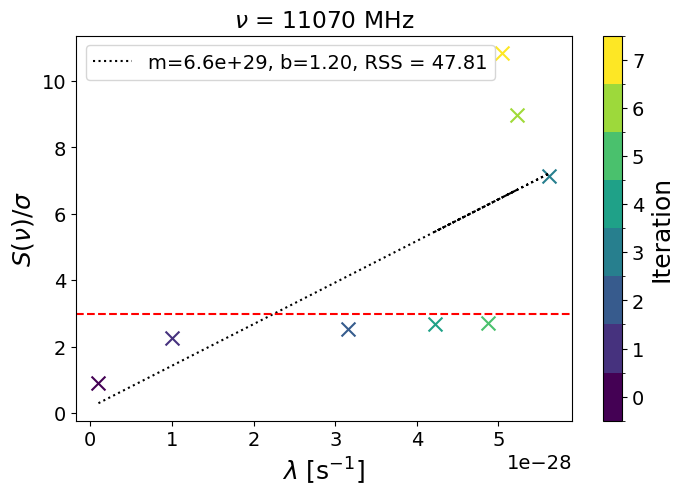

In [51]:
plot_freq_pvals(2, 11070)

## Correlation coefficients

In [53]:
pval_example = np.load('/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/0/8760_pvals.npy')
sizes, vals = pval_example
vals = np.sqrt(2) * erfcinv(2 * vals)
matrix = np.corrcoef(sizes, vals)
matrix[0][1]

0.9998839853801493

Bank 0:
[8200 8590 8700 8820]
Percent bad: 3.4%
Bank 1:
[8710 9220 9250 9330 9340 9460 9480 9490 9560 9610 9630 9720 9860]
Percent bad: 9.6%
Bank 2:
[ 9830  9850  9950 10010 10540 10560 10640 10670 10880 10910 10920 10990
 11000 11010 11050 11060 11070 11080 11090 11100 11110 11170]
Percent bad: 16.3%


Text(0, 0.5, '$A_I(\\nu)$')

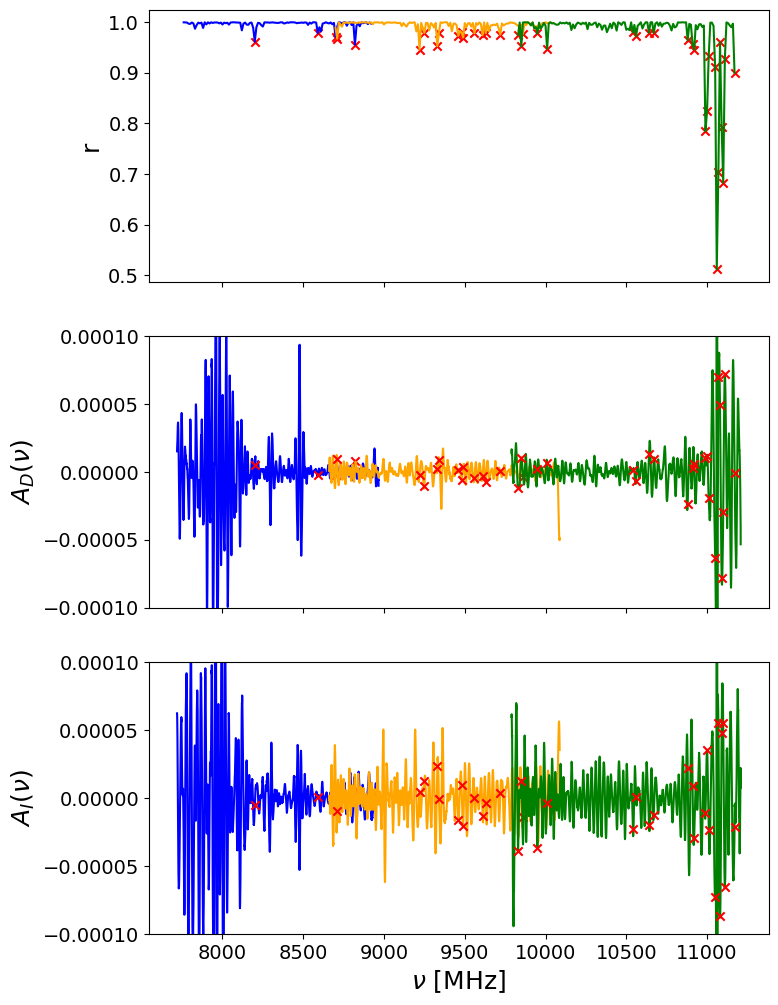

In [65]:
colors = ['blue', 'orange', 'green']
analysis_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/'

def key(l):
    return int(l.split('_')[0])

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8,12), sharex=True)

for bank, color in enumerate(colors):
    print(f'Bank {bank}:')
    bank_dir = os.path.join(analysis_dir, str(bank))
    files = [file for file in os.listdir(bank_dir) if ('pvals' in file) and ('uninj' not in file)]
    sorted_files = sorted(files, key=key)
    pvals_list = np.array([np.load(os.path.join(bank_dir, file)) for file in sorted_files])

    def get_pearson_r(pvals):
        sizes, vals = pvals
        corrs = np.sqrt(2) * erfcinv(2 * vals)
        matrix = np.corrcoef(sizes, corrs)
        return matrix[0][1]

    rs = np.array([get_pearson_r(pvals) for pvals in pvals_list])
    freqs = np.array(list(map(key, sorted_files)))

    # A bad fit whenever r < 0.98
    inds = np.where(rs < 0.98)[0]
    percent = len(inds) / len(rs)
    bad_freqs = freqs[inds]
    print(bad_freqs)
    print(f'Percent bad: {(percent * 100):.1f}%')

    ax1.plot(freqs, rs, color=color)
    ax1.scatter(bad_freqs, rs[inds], color='r', marker='x')

    dopp = np.load(os.path.join(bank_dir, 'uninj_dopp_asymmetry.npy'))
    inten = np.load(os.path.join(bank_dir, 'uninj_int_asymmetry.npy'))

    xs = dopp[0]
    ax2.plot(*dopp, color=color)
    ax3.plot(*inten, color=color)

    if bad_freqs.size:
        bad_freq_inds = np.array([np.argmin(np.abs(xs-freq)) for freq in bad_freqs])
        bad_dopp = dopp[1, bad_freq_inds]
        ax2.scatter(bad_freqs, bad_dopp, color='r', marker='x', zorder=2)
        bad_inten = inten[1, bad_freq_inds]
        ax3.scatter(bad_freqs, bad_inten, color='r', marker='x', zorder=2)

ax2.set_ylim(-1e-4, 1e-4)
ax3.set_ylim(-1e-4, 1e-4)
ax3.set_xlabel(r'$\nu$ [MHz]', fontsize=18)
ax1.set_ylabel('r', fontsize=18)
ax2.set_ylabel(r'$A_D(\nu)$', fontsize=18)
ax3.set_ylabel(r'$A_I(\nu)$', fontsize=18)

In [60]:
def plot_freq_pvals(bank, freq):
    pval_example = np.load(f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/{bank}/{freq}_pvals.npy')
    sizes, vals = pval_example
    vals = np.sqrt(2) * erfcinv(2 * vals)

    fig, ax = plt.subplots(figsize=(8,5))

    cmap = plt.get_cmap('viridis')
    colors = cmap(np.linspace(0, 1, len(sizes)))
    for i in range(len(sizes)):
        ax.scatter(sizes[i], vals[i], marker='x', color=colors[i], s=100)

    import matplotlib as mpl
    import matplotlib.colors as mcolors

    bounds = np.arange(len(sizes)+1)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    discrete_cmap = mcolors.ListedColormap(colors)
    cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=mpl.colormaps['viridis'])) # Ticks in the middle of intervals
    cbar.set_label('Iteration', fontsize=18)
    cbar.set_ticks(bounds[:-1]+0.5)
    cbar.set_ticklabels(bounds[:-1])

    fit = Polynomial.fit(sizes, vals, 1)
    r = np.corrcoef(sizes, vals)[0][1]
    ax.plot(sizes, fit(sizes), c='k', ls=':', label=f'm={m:.2g}, b={b:.2f}, r={r:.2f}')

    ax.axhline(3, c='red', ls='--')
    ax.set_xlabel('$\lambda$ [s$^{-1}$]', fontsize=18)
    ax.set_ylabel(r'$S(\nu) / \sigma$', fontsize=18)
    ax.set_title(rf'$\nu$ = {freq} MHz')
    ax.legend()

/tmp/ipykernel_1657381/3656675638.py:19: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=mpl.colormaps['viridis'])) # Ticks in the middle of intervals


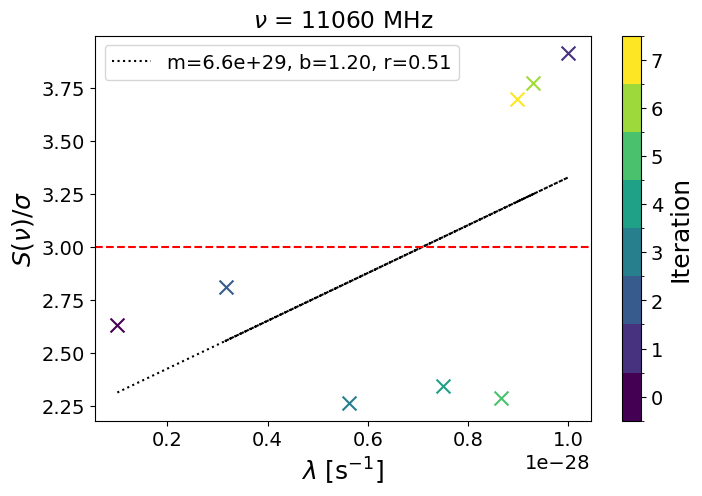

In [ ]:
plot_freq_pvals(2, 11060)

/tmp/ipykernel_1657381/3656675638.py:19: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=mpl.colormaps['viridis'])) # Ticks in the middle of intervals


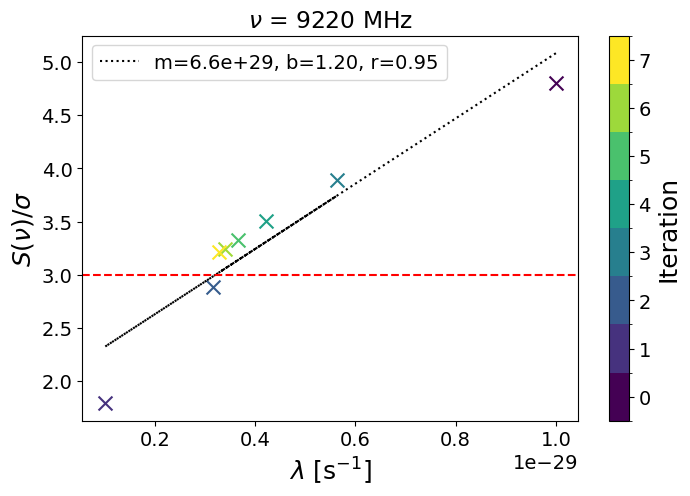

In [66]:
plot_freq_pvals(1, 9220)

## Intercepts

Bank 0:
Bank 1:
Bank 2:


(-1.0, 1.0)

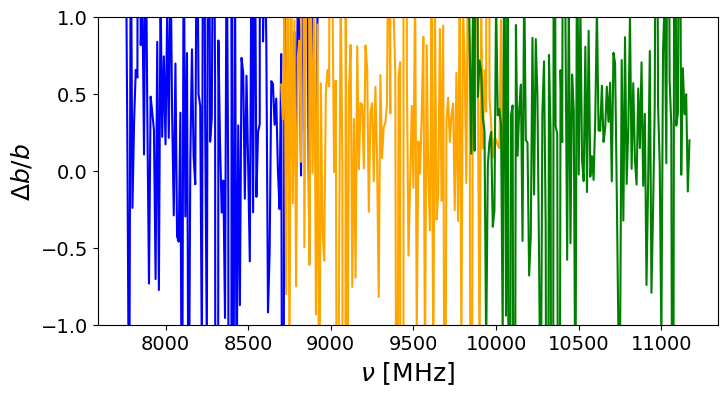

In [74]:
colors = ['blue', 'orange', 'green']
analysis_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/'

def key(l):
    return int(l.split('_')[0])

fig, ax = plt.subplots(1, 1, figsize=(8,4), sharex=True)

for bank, color in enumerate(colors):
    print(f'Bank {bank}:')
    bank_dir = os.path.join(analysis_dir, str(bank))
    files = [file for file in os.listdir(bank_dir) if ('pvals' in file) and ('uninj' not in file)]
    sorted_files = sorted(files, key=key)
    pvals_list = np.array([np.load(os.path.join(bank_dir, file)) for file in sorted_files])

    def get_intercept(pvals):
        sizes, vals = pvals
        corrs = np.sqrt(2) * erfcinv(2 * vals)
        _, b = np.polyfit(sizes, corrs, 1)
        return b

    bs = np.array([get_intercept(pvals) for pvals in pvals_list])
    freqs = np.array(list(map(key, sorted_files)))

    #ax.plot(freqs, bs, color=color)

    dopp = np.load(os.path.join(bank_dir, 'uninj_dopp_asymmetry.npy'))
    inten = np.load(os.path.join(bank_dir, 'uninj_int_asymmetry.npy'))

    # Divide each through by rolling stds.
    def standardize(uninj):
        stds = []
        for i in range(len(uninj)):
            if i < 140:
                stds.append(np.std(uninj[:i+140]))
            elif i >= len(uninj) - 140:
                stds.append(np.std(uninj[i-140:]))
            else:
                stds.append(np.std(uninj[i-140:i+140]))
        return uninj / stds
    
    dopp_sigmas = standardize(dopp[1])
    inten_sigmas = standardize(inten[1])

    pvals_dopp = list(map(lambda sigma: .5*math.erfc(sigma/np.sqrt(2)), dopp_sigmas))
    pvals_int = list(map(lambda sigma: .5*math.erfc(sigma/np.sqrt(2)), inten_sigmas))
    pvals_comb = np.multiply(pvals_dopp, pvals_int)
    corr_comb = np.sqrt(2) * erfcinv(2 * pvals_comb)
    
    xs = dopp[0]
    freq_inds = np.array([np.argmin(np.abs(xs-freq)) for freq in freqs])
    ax.plot(freqs, (bs - corr_comb[freq_inds]) / bs, color=color)

ax.set_xlabel(r'$\nu$ [MHz]', fontsize=18)
ax.set_ylabel('$\Delta b / b$', fontsize=18)
ax.set_ylim(-1, 1)